# Data Analysis & Preprocessing



This notebook contains the full data preparation process:

 1. Data consistency assessment
 2. Choosing relevant features
 3. Ascertaining whether stacking seasons as features causes dimentionality issues 
 4. Identifying NaN values & treating them accordingly
 5. Considering multi-algorithm decision process for different roles 

## Frameworks & Libraries

In [38]:
import sys
sys.path.append("../devkit")
from utils import mkSeasonDf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import textwrap

## Data Setup

In [39]:
df21 = mkSeasonDf("2021-2022")
df22 = mkSeasonDf("2022-2023")
df23 = mkSeasonDf("2023-2024")
df24 = mkSeasonDf("2024-2025")
df25 = mkSeasonDf("2025-2026")

dfs = {"20-21": df21, "20-21": df22, "20-21":df23,
       "20-21": df24, "20-21": df25}

In [40]:
# Checks for invalid column sizes
for i in dfs.values(): print(f"FLAGGED [{i}]: under 16 columns! ({len(i.columns)}):") if len(i.columns) < 16 else None

In [41]:
df21.head()

,league,Player,Team,Team within selected timeframe,Position,Age,Market value,Contract expires,Matches played,Minutes played,...,Prevented goals per 90,Back passes received as GK per 90,Exits per 90,Aerial duels per 90.1,Free kicks per 90,Direct free kicks per 90,"Direct free kicks on target, %",Corners per 90,Penalties taken,"Penalty conversion, %"
0,2. Bundesliga,M. Thiaw,Newcastle United,Schalke 04,RCB,24,25000000,2029-06-30,31,2718,...,NaN,2.98,NaN,NaN,0.00,0.00,0.0,0.00,0,0.0
1,2. Bundesliga,N. Füllkrug,Milan,Werder Bremen,CF,33,15000000,2028-06-30,33,2693,...,NaN,0.00,NaN,NaN,0.00,0.00,0.0,0.03,2,100.0
2,2. Bundesliga,J. Beste,Freiburg,Jahn Regensburg,"RW, RAMF",27,15000000,2030-06-30,26,2077,...,NaN,0.22,NaN,NaN,0.52,0.04,100.0,2.64,0,0.0
3,2. Bundesliga,K. Itakura,Ajax,Schalke 04,"CB, RCB",29,12000000,2029-06-30,31,2838,...,NaN,2.66,NaN,NaN,0.00,0.00,0.0,0.00,0,0.0
4,2. Bundesliga,E. Dinkçi,Heidenheim,Werder Bremen,"RW, RAMF, CF",24,12000000,2026-06-30,21,701,...,NaN,0.00,NaN,NaN,0.00,0.00,0.0,0.00,0,0.0


### Separating By Roles

In [42]:
miss = pd.DataFrame({y: d.isna().mean().mul(100) for y, d in dfs.items()})  # rows=columns, cols=years

In [43]:
def nan_groups(df, name="", verbose=1, drop_zero=False, ax=None):
    """Group columns by identical NaN counts. Plot group sizes vs % NaN, then list members."""
    n_rows = len(df)
    nan_count = df.isna().sum()
    if drop_zero:
        nan_count = nan_count[nan_count > 0]
    if nan_count.empty:
        print(f"{name}: no NaNs anywhere")
        return {}

    pct = (nan_count / n_rows * 100).round(2)
    groups = {p: list(pct.index[pct == p]) for p in sorted(pct.unique(), reverse=False)}

    # ---------- plot ----------
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    xs = [f"{p:.2f}%" for p in groups]
    ys = [len(v) for v in groups.values()]
    pos = range(len(xs))

    bars = ax.bar(pos, ys, color="steelblue", width=0.75)
    top = max(ys)
    for b, y in zip(bars, ys):
        inside = b.get_height() >= top * 0.08          # too short to hold a label
        ax.text(b.get_x() + b.get_width() / 2,
                b.get_height() - top * 0.03 if inside else b.get_height() + top * 0.015,
                str(y),
                ha="center", va="top" if inside else "bottom",
                fontsize=8, fontweight="bold",
                color="white" if inside else "black")

    ax.set_xticks(pos, xs, rotation=90, fontsize=8)
    ax.set_ylim(0, top * 1.12)
    ax.set_xlabel("% NaN")
    ax.set_ylabel("columns in group")
    ax.set_title(f"{name}  —  {len(pct)} columns, {len(groups)} distinct NaN levels")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

    # ---------- print ----------
    if verbose:
        width = max(len(f"{p:.2f}") for p in groups)
        print(f"\n{'=' * 70}\n{name}   ({n_rows} rows, {len(pct)} columns)\n{'=' * 70}")
        for p, cols in groups.items():
            members = cols if verbose >= 2 else [df.columns.get_loc(c) for c in cols]
            body = ", ".join(map(str, members))
            head = f"{p:>{width}.2f}%  n={len(cols):<4}"
            print(textwrap.fill(body, width=100, initial_indent=head + " [",
                    subsequent_indent=" " * (len(head) + 2)) + "]")
    return groups


20-21   (39650 rows, 116 columns)
 0.00%  n=31   [0, 1, 3, 5, 6, 8, 9, 10, 11, 12, 13, 19, 20, 21, 28, 31, 33, 35, 39, 42, 44, 47, 78,
                79, 97, 99, 101, 102, 103, 114, 115]
 0.04%  n=1    [4]
 0.05%  n=2    [16, 17]
 7.32%  n=3    [34, 36, 38]
 7.36%  n=67   [14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 37, 40, 41, 43, 45, 46, 48, 49, 50, 51,
                52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72,
                73, 74, 75, 76, 77, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95,
                96, 104, 107, 113]
 8.21%  n=1    [2]
13.85%  n=1    [18]
14.77%  n=3    [110, 111, 112]
40.30%  n=1    [7]
92.39%  n=1    [105]
92.60%  n=5    [98, 100, 106, 108, 109]


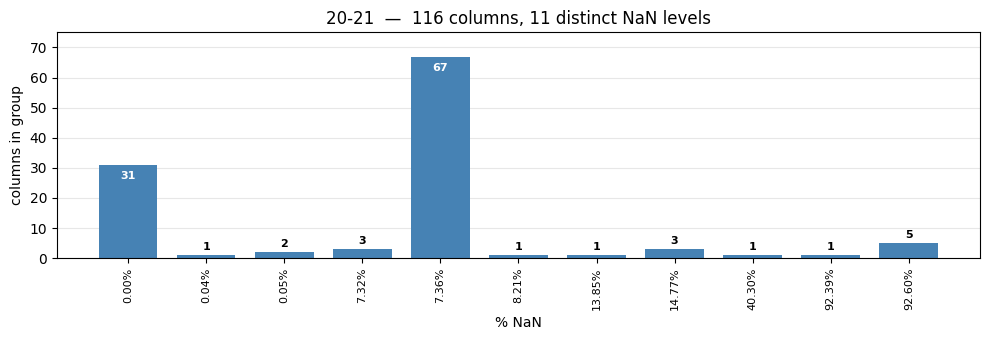

In [44]:
fig, axes = plt.subplots(len(dfs), 1, figsize=(10, 3.5 * len(dfs)), squeeze=False)
all_groups = {
    year: nan_groups(df, name=year, verbose=1, ax=axes[i, 0])
    for i, (year, df) in enumerate(dfs.items())
}
plt.tight_layout()

## TODO

 1. Keep downloading all green leagues for all years (except those that require more than `Age`, for now)
 2. Use [0-potential_output_analysis.ipynb](0-potential_output_analysis.ipynb)'s tables (see below) to separate dataframes by roles (will be important to remove irrelevant columns from specific roles, like strikers having NaN for goals stopped)

<br>

<div style="display:flex; gap:24px; align-items:flex-start; justify-content:center;">

<table>
<thead><tr><th>Role</th><th>Code</th><th>Full position</th></tr></thead>
<tbody>
<tr><td><b>GK</b></td><td><code>GK</code></td><td>Goalkeeper (Guarda-redes)</td></tr>
<tr><td rowspan="3"><b>CB</b></td><td><code>CB</code></td><td>Centre-back (Defesa-central)</td></tr>
<tr><td><code>RCB</code></td><td>Right centre-back (Defesa-central direito)</td></tr>
<tr><td><code>LCB</code></td><td>Left centre-back (Defesa-central esquerdo)</td></tr>
<tr><td rowspan="4"><b>FB</b></td><td><code>RB</code></td><td>Right-back (Lateral direito)</td></tr>
<tr><td><code>LB</code></td><td>Left-back (Lateral esquerdo)</td></tr>
<tr><td><code>RWB</code></td><td>Right wing-back (Ala direito)</td></tr>
<tr><td><code>LWB</code></td><td>Left wing-back (Ala esquerdo)</td></tr>
<tr><td rowspan="3"><b>DM</b></td><td><code>DMF</code></td><td>Defensive midfielder (Médio defensivo)</td></tr>
<tr><td><code>RDMF</code></td><td>Right defensive midfielder (Médio defensivo direito)</td></tr>
<tr><td><code>LDMF</code></td><td>Left defensive midfielder (Médio defensivo esquerdo)</td></tr>
</tbody>
</table>

<table>
<thead><tr><th>Role</th><th>Code</th><th>Full position</th></tr></thead>
<tbody>
<tr><td rowspan="3"><b>CM</b></td><td><code>CMF</code></td><td>Central midfielder (Médio-centro)</td></tr>
<tr><td><code>RCMF</code></td><td>Right central midfielder (Médio-centro direito)</td></tr>
<tr><td><code>LCMF</code></td><td>Left central midfielder (Médio-centro esquerdo)</td></tr>
<tr><td><b>AM</b></td><td><code>AMF</code></td><td>Attacking midfielder (Médio ofensivo)</td></tr>
<tr><td rowspan="6"><b>W</b></td><td><code>LW</code></td><td>Left winger (Extremo esquerdo)</td></tr>
<tr><td><code>RW</code></td><td>Right winger (Extremo direito)</td></tr>
<tr><td><code>LWF</code></td><td>Left wing forward (Extremo-avançado esquerdo)</td></tr>
<tr><td><code>RWF</code></td><td>Right wing forward (Extremo-avançado direito)</td></tr>
<tr><td><code>LAMF</code></td><td>Left attacking midfielder / wide (Médio ofensivo esquerdo)</td></tr>
<tr><td><code>RAMF</code></td><td>Right attacking midfielder / wide (Médio ofensivo direito)</td></tr>
<tr><td><b>CF</b></td><td><code>CF</code></td><td>Centre-forward (Ponta de lança)</td></tr>
</tbody>
</table>

</div>

<br>
<br>